## Analysing the density of performances based on the IAAF Score over the years

Hypothesis: Performance density is decreasing over the years

In [100]:
# Load data

import sys
from pathlib import Path

# Path to the parent folder (where util.py is)
parent_path = Path().resolve().parent.parent  # notebook's parent directory
sys.path.append(str(parent_path))
import util
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import help_functions as hp

data = util.load_data(path_file='C:\\Users\\Mattis\\OneDrive\\Kogni\\DataLiteracyProject\\Data-Literacy\\data_csv\\Data.csv') 

data.head()

,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort,iaaf_score
0,2017,W,Frauen,100 m,10.95,"+1,3",Gina Lueckenkemper,1996,LG Olympia Dortmund,05.08.,London/GBR,1211
1,2017,W,Frauen,100 m,11.06,"+1,8",Rebekka Haase,1993,LV 90 Erzgebirge,25.05.,Zeulenroda,1187
2,2017,W,Frauen,100 m,11.14,"-0,2",Lisa Mayer,1996,Sprintteam Wetzlar,27.08.,Berlin,1169
3,2017,W,Frauen,100 m,11.24,"+0,3",Tatjana Pinto,1992,LC Paderborn,15.07.,Ninove/BEL,1148
4,2017,W,Frauen,100 m,11.25,"+1,9",Sina Mayer,1995,LAZ Zweibruecken,11.06.,Regensburg,1146


Data clearing of outliers and defining discipline groups for further investigation

In [101]:
# Exclude outliers that are not explainable

data = data[(data["iaaf_score"] < 1380) & (data["iaaf_score"] > 20)]

# Define Discipline groups NOTE: Only the ones with clear data

run_disciplines = ['800 m', '1500 m', '3000 m', '5000 m', '10 km']
sprint_disciplines = ['100 m', '200 m', '400 m']
throw_disciplines = ['Kugelstoss', 'Diskuswurf', 'Hammerwurf', 'Speerwurf']
jump_disciplines = ['Hochsprung', 'Stabhochsprung', 'Weitsprung', 'Dreisprung']

# Combine all into a single list
all_disciplines = run_disciplines + sprint_disciplines + throw_disciplines + jump_disciplines

data = data[data["disziplin"].isin(all_disciplines)]

### How is the performance evolving for the elite (e.g. Top 3) in comarison to the second/third row (e.g. Top 10/20/30) over the years

**NOTE**: Not more than top 30 to have always the same amount of data for comparability

1. The top-X performances are taken for every discipline x gender x age group seperatly -> calculation of mean and standard deviation for every group

2. We first look at all disciplines/Gender/Age Group together -> mean aggregated over all groups per year

3. Plotting the difference of mean performance to the first recorded year, e.g. 2001 -> over 1.0 -> increase in peformance, under 1.0 -> decrease in performance 

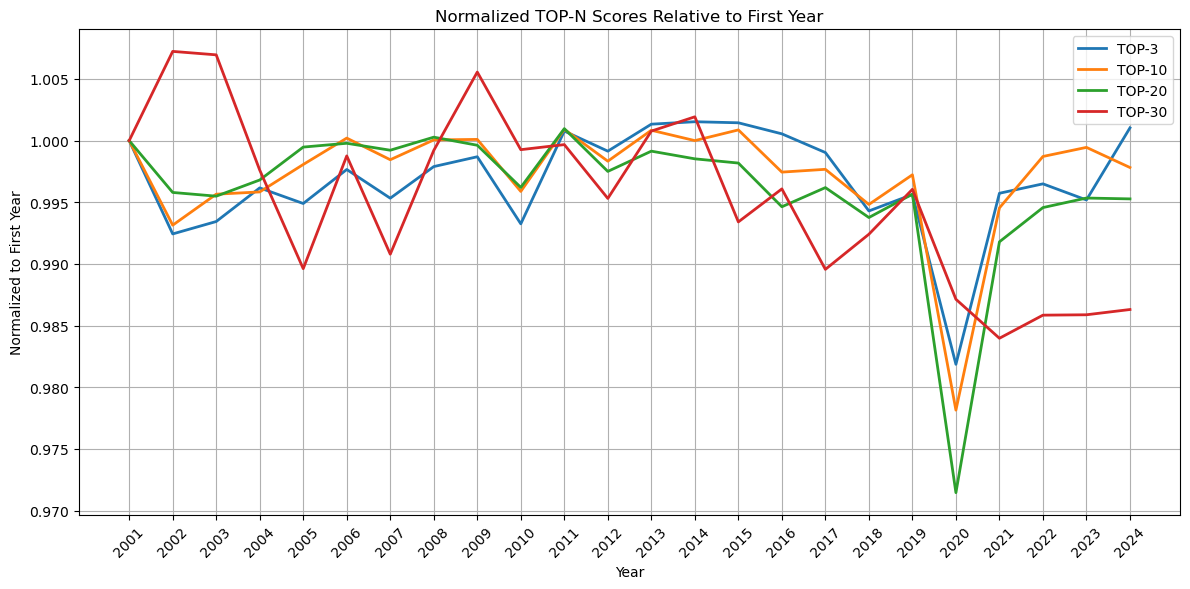

In [159]:
import matplotlib.pyplot as plt 
import pandas as pd 

top_entries_list = [3, 10, 20, 30] 
normalized_stats_list = [] 

for n in top_entries_list: 
    # Collect top-N entries
    top_stats, top_raw = hp.collect_top_entries(data, num_entries=n) 
    if top_raw.empty: 
        continue 
    
    # Compute mean TOP-N per year
    top_n_mean = top_raw.groupby("jahr")["iaaf_score"].mean().reset_index(name="top_mean") 
    
    # Normalize to first year
    first_year_value = top_n_mean["top_mean"].iloc[0] 
    top_n_mean["normalized"] = top_n_mean["top_mean"] / first_year_value 
    
    # Add a column with number of entries for legend
    top_n_mean["num_entries"] = n
    
    # Append to list
    normalized_stats_list.append(top_n_mean) 
    
# Plot normalized TOP-N scores
plt.figure(figsize=(12, 6)) 

for stats in normalized_stats_list: 
    plt.plot(stats["jahr"], stats["normalized"], label=f"TOP-{stats['num_entries'].iloc[0]}", linewidth=2) 

plt.xlabel("Year") 
plt.ylabel("Normalized to First Year") 
plt.title("Normalized TOP-N Scores Relative to First Year") 
plt.legend() 
plt.grid(True) 
plt.xticks(sorted(data["jahr"].unique()), rotation=45) 
plt.tight_layout() 
plt.show()


#### Interpretation

- We can see a clear drop in 2020 (Corona performances)
- Top 30 is decreasing more or less since 2014 (no Corona effect; Top Performances more affected?!)



### Looking at the overall density of performances e.g. the Standard deviation

Standard deviation is a good indicator of how dense a distribution is

- p-value -> tests the null hypothesis that the slope of the regression line is zero (e.g. no relationship)
- R^2 -> Explains how much of variation in dependent variable (e.g. std dev) is explained by independent variable (e.g. years) (Range 0: Dependent explains no variation; 1: Dependent explains all variation)

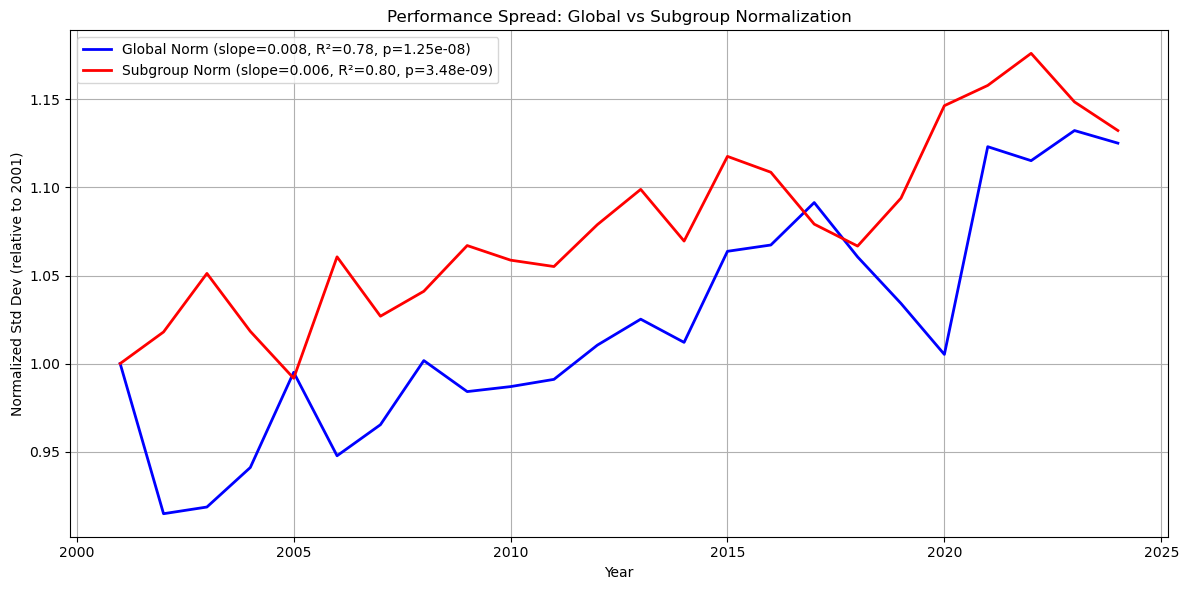

In [168]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.api as sm

# --- 1. Global normalization ---
top_stats, top_raw = hp.collect_top_entries(data, num_entries=30)

# Std per year
global_std = top_raw.groupby('jahr')['iaaf_score'].std()
global_std_norm = global_std / global_std.iloc[0]  # normalize to first year

# Linear regression
years = global_std_norm.index.values.astype(float)
X = sm.add_constant(years)
model_global = sm.OLS(global_std_norm.values, X).fit()
slope_global = model_global.params[1]
r2_global = model_global.rsquared
p_global = model_global.pvalues[1]

# --- 2. Subgroup normalization ---
subgroup_norm_series = []

for (disc, gender, age), subdf in top_raw.groupby(["disziplin", "geschlecht", "altersklasse"]):
    depth_std = subdf.groupby("jahr")["iaaf_score"].std()
    if 2001 not in depth_std.index:
        continue
    norm = depth_std / depth_std.loc[2001]
    subgroup_norm_series.append(norm)


# Combine subgroups
norm_df = pd.concat(subgroup_norm_series, axis=1)
subgroup_mean_norm = norm_df.mean(axis=1)
subgroup_mean_norm = subgroup_mean_norm.sort_index()
# Linear regression
years_sub = subgroup_mean_norm.index.values.astype(float)
X_sub = sm.add_constant(years_sub)
model_subgroup = sm.OLS(subgroup_mean_norm.values, X_sub).fit()
slope_sub = model_subgroup.params[1]
r2_sub = model_subgroup.rsquared
p_sub = model_subgroup.pvalues[1]

# --- 3. Plot ---
plt.figure(figsize=(12,6))
plt.plot(global_std_norm.index, global_std_norm.values, color='blue', linewidth=2,
         label=f'Global Norm (slope={slope_global:.3f}, R²={r2_global:.2f}, p={p_global:.2e})')
plt.plot(subgroup_mean_norm.index, subgroup_mean_norm.values, color='red', linewidth=2,
         label=f'Subgroup Norm (slope={slope_sub:.3f}, R²={r2_sub:.2f}, p={p_sub:.2e})')
plt.xlabel("Year")
plt.ylabel("Normalized Std Dev (relative to 2001)")
plt.title("Performance Spread: Global vs Subgroup Normalization")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


#### Interpretation

Standard deviation is clearly increasing -> drop in performance density

There clearly is an significant effect nevertheless if subgroup or global normalization. 

### Looking at age group, gender, discipline to find the disciplines that are struggling

1. Idea: Looking at the discipline groups; That is a division the DLV is doing (and makes sense to me)

2. Looking at gender

3. Looking at age groups x gender

To further exclude absolute performance differences all calculations are done with normalization in the subgroups


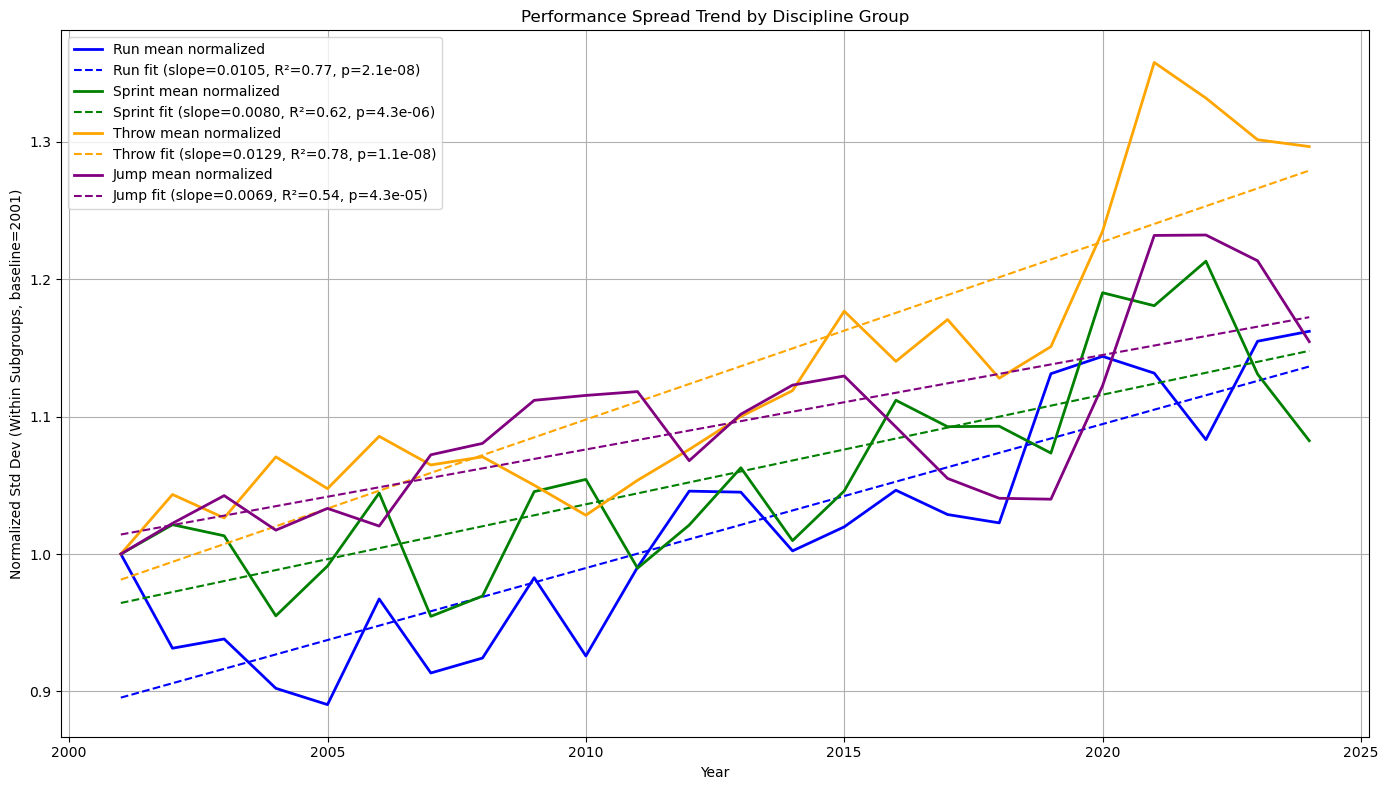

In [155]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd

groups = {
    'Run': run_disciplines,
    'Sprint': sprint_disciplines,
    'Throw': throw_disciplines,
    'Jump': jump_disciplines
}

plt.figure(figsize=(14,8))

colors = {
    'Run': 'blue',
    'Sprint': 'green',
    'Throw': 'orange',
    'Jump': 'purple'
}

# Loop over discipline groups
for group_name, disciplines in groups.items():

    group_data = data[data['disziplin'].isin(disciplines)]

    # Collect normalized subgroup time series
    subgroup_norm_series = []

    # Loop over gender × age × discipline
    for (disc, gender, age), subdf in group_data.groupby(["disziplin", "geschlecht", "altersklasse"]):

        if len(subdf["jahr"].unique()) < 2:
            continue  # skip insufficient data

        # yearly std deviation for this subgroup
        depth_std = subdf.groupby("jahr")["iaaf_score"].std()

        # must contain 2001 to normalize
        if 2001 not in depth_std.index:
            continue

        # normalize subgroup
        norm = depth_std / depth_std.loc[2001]

        subgroup_norm_series.append(norm)

    # Combine subgroup-normalized series (mean across all)
    if len(subgroup_norm_series) == 0:
        continue

    # Align indices and average
    norm_df = pd.concat(subgroup_norm_series, axis=1)
    mean_norm = norm_df.mean(axis=1)

    # Regression
    years = mean_norm.index.astype(float)
    values = mean_norm.values

    X = sm.add_constant(years)
    model = sm.OLS(values, X).fit()

    slope = model.params[1]
    r2 = model.rsquared
    p_value = model.pvalues[1]

    regression_line = model.predict(X)

    # Plot mean normalized values
    plt.plot(years, values, color=colors[group_name], linewidth=2,
             label=f"{group_name} mean normalized")

    # Plot regression line
    plt.plot(years, regression_line, linestyle="--", color=colors[group_name],
             label=f"{group_name} fit (slope={slope:.4f}, R²={r2:.2f}, p={p_value:.1e})")


plt.xlabel("Year")
plt.ylabel("Normalized Std Dev (Within Subgroups, baseline=2001)")
plt.title("Performance Spread Trend by Discipline Group")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


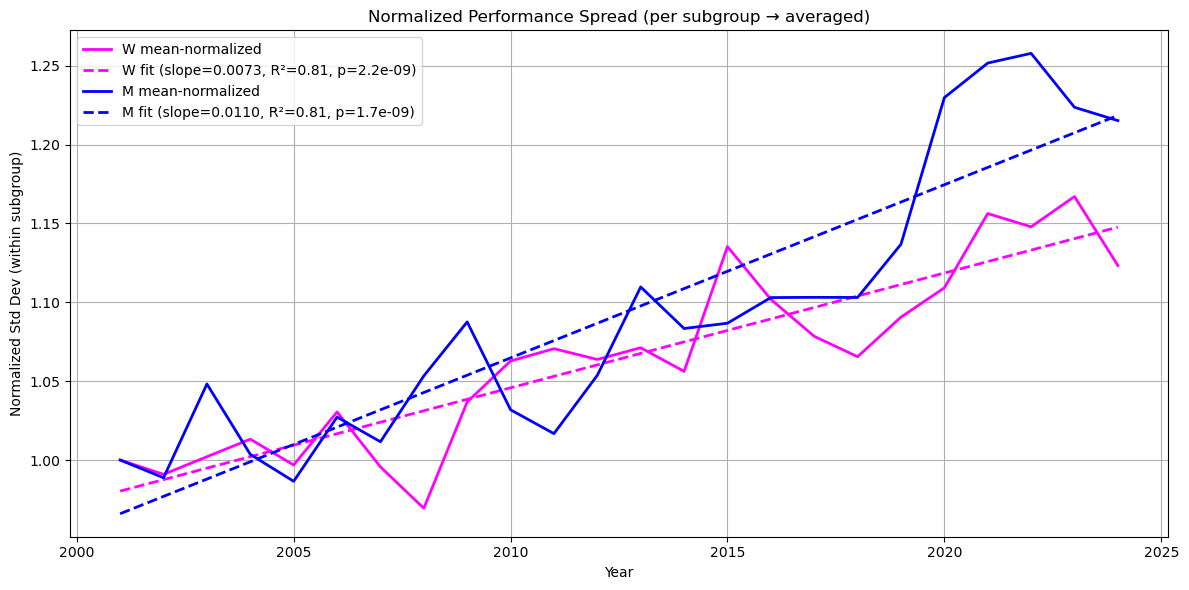

In [154]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np



genders = ["W", "M"]
colors = {"W": "magenta", "M": "blue"}

plt.figure(figsize=(12, 6))

for gender in genders:
    
    gender_data = data[data["geschlecht"] == gender]

    # All discipline × age groups
    disciplines = gender_data["disziplin"].unique()
    age_groups = ["18", "20", "U23", "Maenner", "Frauen"]

    normalized_curves = []

    # ---- 1. Normalize every subgroup separately ----
    for disc in all_disciplines:
        for ak in age_groups:

            sub = gender_data[
                (gender_data["disziplin"] == disc) &
                (gender_data["altersklasse"] == ak)
            ]

            if sub.empty:
                continue

            # std per year for this subgroup
            yearly_std = sub.groupby("jahr")["iaaf_score"].std()

            # must contain 2001 to normalize
            if 2001 not in yearly_std.index:
                continue

            first_year = yearly_std.loc[2001]
            if pd.isna(first_year) or first_year == 0:
                continue

            normalized = yearly_std / first_year

            normalized_curves.append(normalized)

    # ---- 2. Merge all subgroup-curves into a DataFrame ----
    aligned = pd.concat(normalized_curves, axis=1)

    # ---- 3. Mean across all subgroup curves ----
    mean_curve = aligned.mean(axis=1)
    
    # Remove years with too few subgroups
    mean_curve = mean_curve.dropna()

    years = mean_curve.index.values.astype(float)
    vals = mean_curve.values

    # ---- 4. Regression ----
    X = sm.add_constant(years)
    model = sm.OLS(vals, X).fit()

    slope = model.params[1]
    r2 = model.rsquared
    p_value = model.pvalues[1]

    regression_line = model.predict(X)

    # ---- 5. Plot averaged normalized curve ----
    plt.plot(years, vals, color=colors[gender], linewidth=2,
             label=f"{gender} mean-normalized")

    # ---- 6. Plot regression line ----
    plt.plot(years, regression_line, "--",
             color=colors[gender], linewidth=2,
             label=f"{gender} fit (slope={slope:.4f}, R²={r2:.2f}, p={p_value:.1e})")


plt.xlabel("Year")
plt.ylabel("Normalized Std Dev (within subgroup)")
plt.title("Normalized Performance Spread (per subgroup → averaged)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


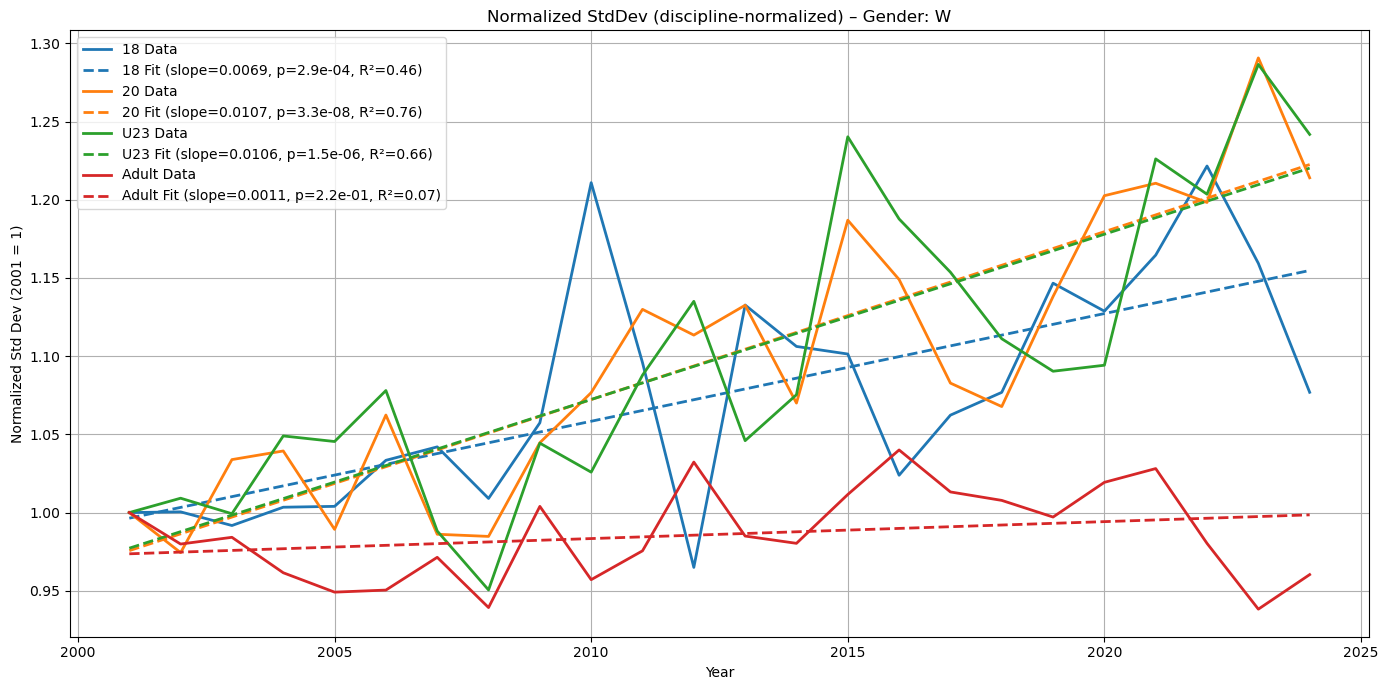

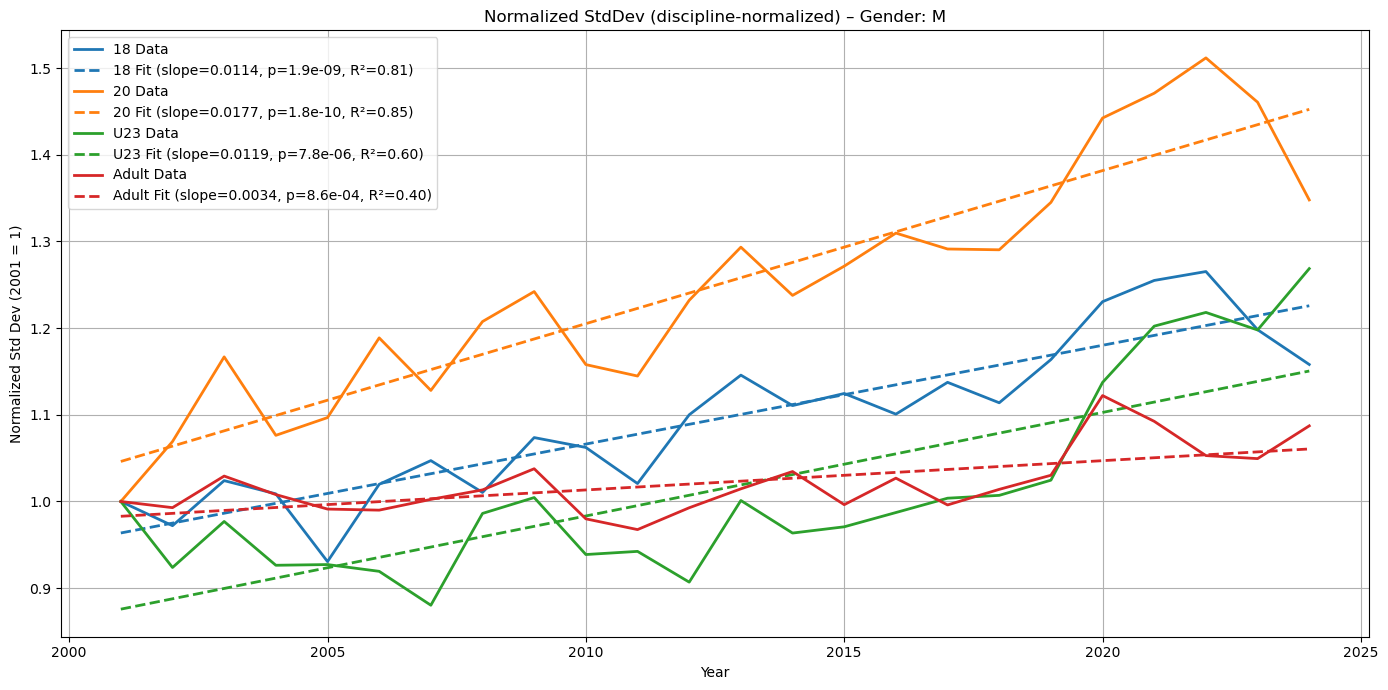

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd

genders = ['W', 'M']
age_groups = ['18', '20', 'U23', 'Adult']

age_colors = {
    '18': '#1f77b4',
    '20': '#ff7f0e',
    'U23': '#2ca02c',
    'Adult': '#d62728'
}

for gender in genders:
    plt.figure(figsize=(14,7))

    for age in age_groups:

        # Fix adult naming in your dataset
        if age == "Adult":
            age_filter = "Frauen" if gender == "W" else "Maenner"
        else:
            age_filter = age

        # Filter to this gender × age
        base_group = data[(data["geschlecht"] == gender) &(data["altersklasse"] == age_filter)]

        if base_group.empty:
            continue

        # ---------------------------------------------
        # 1) Compute std for EACH discipline separately
        # ---------------------------------------------
        std_by_disc = (
            base_group
            .groupby(["disziplin", "jahr"])["iaaf_score"]
            .std()
            .reset_index()
        )

        # ---------------------------------------------
        # 2) Normalize **within discipline**
        # ---------------------------------------------
        normalized_list = []

        for d, frame in std_by_disc.groupby("disziplin"):
            # Ensure 2001 exists
            if 2001 not in frame["jahr"].values:
                continue

            base = frame.loc[frame["jahr"] == 2001, "iaaf_score"].values[0]
            frame = frame.copy()
            frame["norm"] = frame["iaaf_score"] / base
            normalized_list.append(frame)

        if not normalized_list:
            continue

        # Combine all disciplines
        norm_all = pd.concat(normalized_list)

        # ---------------------------------------------
        # 3) Take mean over disciplines
        # ---------------------------------------------
        mean_norm = norm_all.groupby("jahr")["norm"].mean()

        years = mean_norm.index.values.astype(float)
        vals = mean_norm.values

        # ---------------------------------------------
        # 4) Linear regression per subgroup
        # ---------------------------------------------
        X = sm.add_constant(years)
        model = sm.OLS(vals, X).fit()
        slope = model.params[1]
        intercept = model.params[0]
        r2 = model.rsquared
        p_value = model.pvalues[1]

        regression_line = intercept + slope * years

        # ---------------------------------------------
        # 5) Plot the result
        # ---------------------------------------------
        plt.plot(
            years,
            vals,
            linestyle='-',
            color=age_colors[age],
            linewidth=2,
            label=f"{age} Data"
        )
        plt.plot(
            years,
            regression_line,
            linestyle='--',
            color=age_colors[age],
            linewidth=2,
            label=f"{age} Fit (slope={slope:.4f}, p={p_value:.1e}, R²={r2:.2f})"
        )

    plt.title(f"Normalized StdDev (discipline-normalized) – Gender: {gender}")
    plt.xlabel("Year")
    plt.ylabel("Normalized Std Dev (2001 = 1)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


#### Interpretation

We can see the trend to higher std. in nearly all distributions tested. Key takeaways:

1. Decrease in density in running is highest
2. Decrease in density is higher in men than in woman
3. Only Increase in density: In U18 Women interestingly